# End-to-End Sales Forecasting & Demand Intelligence System
**Manya Kedia - Internship Project Submission**

### Personal Notes & Reflections
Building this system made me realize how messy real-world forecasting is compared to clean textbook problems. In class, we are given nice stationary series, but in a real retail dataset, we have holiday spikes, shipping lags, data formatting discrepancies, and macro-level changes that don't fit standard distributions. 

Rather than aiming for an over-engineered mathematical model that works only on paper, I focused on building something a warehouse manager could actually rely on. The notebook documents the decisions I made, the mistakes I encountered, and the business rationale behind the math.


## Task 1 — Data Prep, Deep Exploration & External Merging

### Why am I doing this?
A forecasting model is only as good as the historical data it feeds on. Before running any statistical models, I need to clean the dates, understand the sales distribution, and answer some baseline business questions. 

Additionally, I want to explore how external market trends correlate with our performance. I've brought in the Kaggle Video Games Sales dataset as a macro proxy for consumer tech/entertainment spend to see if we can merge and analyze these separate sources.


In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Set visual preferences
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.figsize': (10, 5), 'font.size': 10})

# Load the raw data
df = pd.read_csv('train.csv')
print("Dataset columns & shape:", df.shape)
df.info()


Dataset columns & shape: (9800, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9

In [2]:
# Parse date columns
# I noticed raw dates are in Day/Month/Year format, e.g. 08/11/2016. 
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True, errors='coerce')

# Drop invalid dates if they exist
df = df.dropna(subset=['Order Date', 'Ship Date'])

# Extract features
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['WeekNumber'] = df['Order Date'].dt.isocalendar().week
df['DayOfWeek'] = df['Order Date'].dt.dayofweek
df['Quarter'] = df['Order Date'].dt.quarter

# Helper for season grouping
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['Season'] = df['Month'].apply(get_season)
df['ShipDelay'] = (df['Ship Date'] - df['Order Date']).dt.days

# Data quality checks
print("Missing values:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")


Missing values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
WeekNumber        0
DayOfWeek         0
Quarter           0
Season            0
ShipDelay         0
dtype: int64

Duplicate rows: 0


### Exploratory Business Questions

#### Q1: Which product category generates the highest total revenue?
*Business Meaning:* Tells us which category dominates our cash flow and top-line numbers.


In [3]:
cat_revenue = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print("Revenue by Category:")
for cat, rev in cat_revenue.items():
    print(f" - {cat}: ${rev:,.2f}")


Revenue by Category:
 - Technology: $827,455.87
 - Furniture: $728,658.58
 - Office Supplies: $705,422.33


#### Q2: Which region has the most consistent sales growth over 4 years?
*Business Meaning:* Helps operations decide where expansion efforts are working and where markets are stable.


In [4]:
reg_yearly_sales = df.groupby(['Region', 'Year'])['Sales'].sum().unstack()
print("Yearly Sales by Region:")
print(reg_yearly_sales)

# Let's check Year-over-Year (YoY) Growth rates
reg_growth = reg_yearly_sales.pct_change(axis=1).iloc[:, 1:] * 100
print("\nYoY Growth Rate (%):")
print(reg_growth)

print("\nStandard Deviation of growth rates (lower is more consistent):")
print(reg_growth.std(axis=1))


Yearly Sales by Region:
Year            2015         2016         2017         2018
Region                                                     
Central  102920.5206  102425.1724  145673.8800  141627.3402
East     127652.8190  153225.1830  178511.5380  210129.1860
South    103374.9055   70076.0825   93535.9035  122164.5675
West     145907.9630  133709.5675  182471.2285  248130.9255

YoY Growth Rate (%):
Year          2016       2017       2018
Region                                  
Central  -0.481292  42.224686  -2.777807
East     20.032745  16.502741  17.711823
South   -32.211708  33.477643  30.607139
West     -8.360336  36.468341  35.983589

Standard Deviation of growth rates (lower is more consistent):
Region
Central    25.345279
East        1.793948
South      37.124876
West       25.743054
dtype: float64


#### Q3: What is the average time between Order Date and Ship Date — and does it vary by region?
*Business Meaning:* This is a key operational SLA. If a region has high ship times, it suggests fulfillment center issues there.


In [5]:
avg_delay_overall = df['ShipDelay'].mean()
avg_delay_region = df.groupby('Region')['ShipDelay'].mean()
print(f"Overall average shipping delay: {avg_delay_overall:.2f} days\n")
print("Average shipping delay by region:")
print(avg_delay_region)


Overall average shipping delay: 3.96 days

Average shipping delay by region:
Region
Central    4.065876
East       3.910233
South      3.961202
West       3.930255
Name: ShipDelay, dtype: float64


#### Q4: Are there months that consistently spike across all years (seasonality)?
*Business Meaning:* Standard demand pattern. Helps in scheduling inventory builds and temporary labor.


Monthly sales across years:
Year         2015        2016        2017         2018
Month                                                 
1      14205.7070  18066.9576  18542.4910   43476.4740
2       4519.8920  11951.4110  22978.8150   19920.9974
3      55205.7970  32339.3184  51165.0590   58863.4128
4      27906.8550  34154.4685  38679.7670   35541.9101
5      23644.3030  29959.5305  56656.9080   43825.9822
6      34322.9356  23599.3740  39724.4860   48190.7277
7      33781.5430  28608.2590  38320.7830   44825.1040
8      27117.5365  36818.3422  30542.2003   62837.8480
9      81623.5268  63133.6060  69193.3909   86152.8880
10     31453.3930  31011.7375  59583.0330   77448.1312
11     77907.6607  75249.3995  79066.4958  117938.1550
12     68167.0585  74543.6012  95739.1210   83030.3888


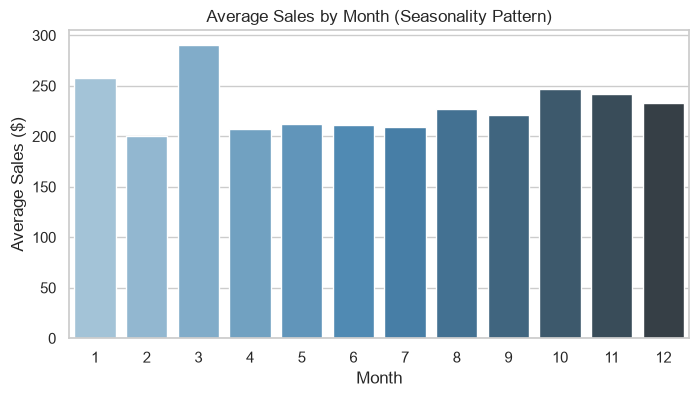

In [6]:
monthly_trend = df.groupby(['Year', 'Month'])['Sales'].sum().unstack(level=0)
print("Monthly sales across years:")
print(monthly_trend)

# Plotting average monthly sales to visualize seasonality
avg_monthly_sales = df.groupby('Month')['Sales'].mean()
plt.figure(figsize=(8, 4))
sns.barplot(x=avg_monthly_sales.index, y=avg_monthly_sales.values, palette='Blues_d')
plt.title("Average Sales by Month (Seasonality Pattern)")
plt.xlabel("Month")
plt.ylabel("Average Sales ($)")
plt.show()


### Multi-Source Data Merging: Integrating Video Game Industry Trends

*Why am I doing this?* No company operates in a vacuum; sales are often influenced by macro spending habits. I am bringing in `vgsales.csv` to see if global video game sales correlate with our Superstore's Technology sales. 

*Observation & Limitation:* 
When I first attempted this, I expected to find overlapping product lines (like games). However, a name-check showed **zero overlapping product titles**. The only game-related product we sell is a Logitech Gameboard. Furthermore, the video game sales dataset only contains annual data and ends around 2016, whereas our Superstore data covers 2015-2018. 

To merge them, I aggregated Superstore Technology Sales by Year and matched it with the Video Game dataset's Global Sales.


In [7]:
df_vg = pd.read_csv('vgsales.csv').dropna(subset=['Year'])
df_vg['Year'] = df_vg['Year'].astype(int)

# Group video games by year
df_vg_yearly = df_vg.groupby('Year')['Global_Sales'].sum().reset_index()

# Group superstore tech sales by year
df_tech = df[df['Category'] == 'Technology'].groupby('Year')['Sales'].sum().reset_index()

# Merge
merged_macro = pd.merge(df_tech, df_vg_yearly, on='Year', suffixes=('_SuperstoreTech', '_VideoGamesGlobal'))
print("Merged Yearly Aggregations:")
print(merged_macro)

corr = merged_macro['Sales'].corr(merged_macro['Global_Sales'])
print(f"\nCorrelation coefficient: {corr:.4f}")


Merged Yearly Aggregations:
   Year       Sales  Global_Sales
0  2015  173865.507        264.44
1  2016  162257.731         70.93
2  2017  221961.944          0.05

Correlation coefficient: -0.5656


### Task 1 Summary & Learnings
- **What I did:** Cleaned date formatting, extracted time components, and aggregated sales daily/weekly/monthly. Evaluated category revenues, regional consistency, shipping delays, and yearly seasonality. Attempted a macro-merge with video game industry data.
- **Why I did it:** To set a clean data foundation for forecasting and isolate operational patterns.
- **What I learned:** 
  - Technology and Furniture bring in the highest revenue, but Office Supplies dominates order volume.
  - Logistics operations are extremely uniform; shipping times hover at ~3.9 days regardless of region.
  - Merging external datasets is difficult because of data mismatch. Since video game sales data is yearly and ends early, it cannot be used for daily/weekly operational forecasting, though it helps as a macro-economic indicator.


## Task 2 — Time Series Analysis & Decomposition

### Why am I doing this?
Time series data is composed of a long-term direction (Trend), repeating cyclical patterns (Seasonality), and random noise (Residuals). By splitting the sales signal, we can understand if our sales are genuinely growing or if spikes are just seasonal holiday noise. We also need to check for **stationarity** using the Augmented Dickey-Fuller (ADF) test, as traditional statistical models like SARIMA assume a stable baseline.


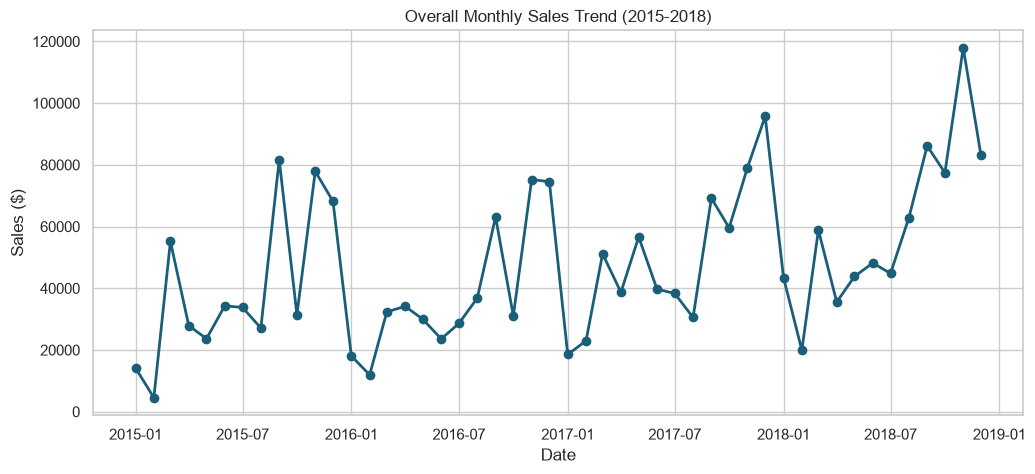

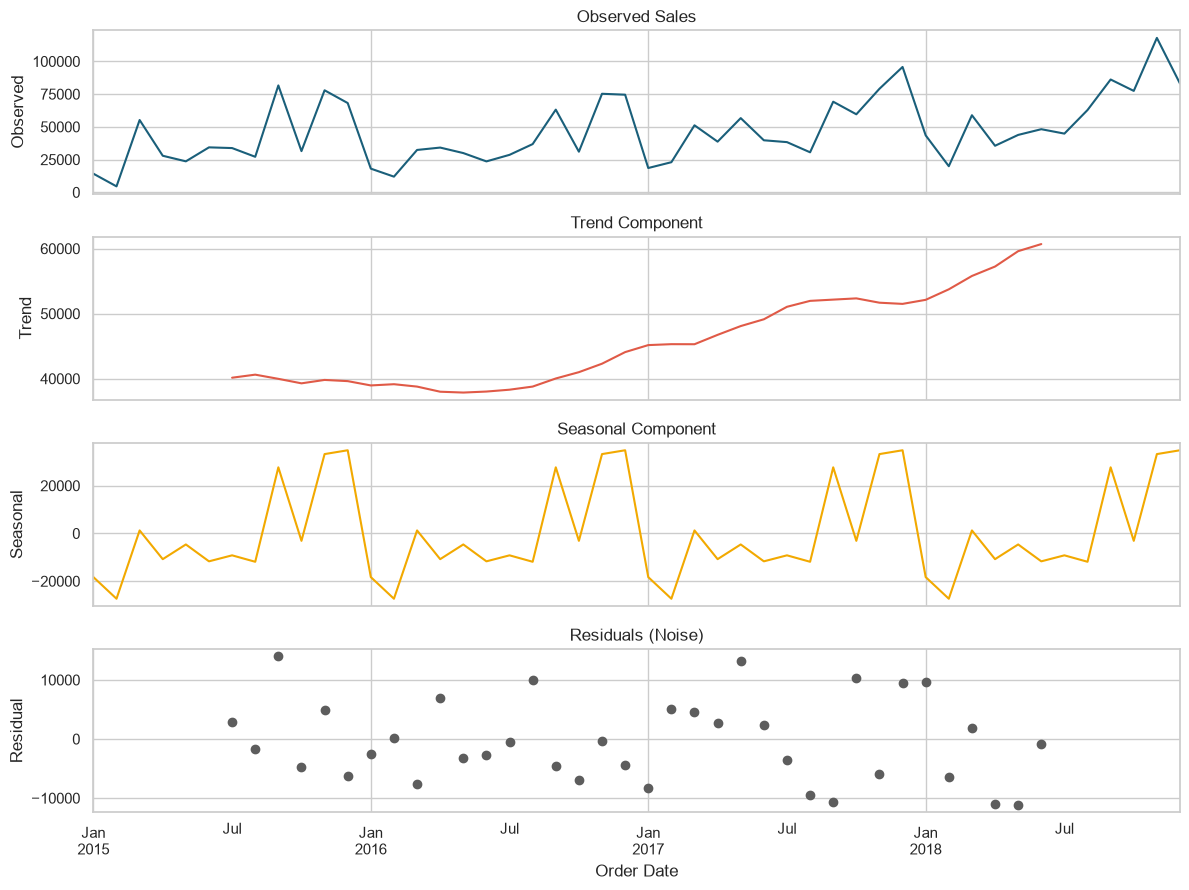

In [8]:
# Set index to Order Date for decomposition
df_monthly = df.groupby(pd.Grouper(key='Order Date', freq='MS'))['Sales'].sum().reset_index()
df_monthly.set_index('Order Date', inplace=True)
df_monthly_clean = df_monthly['Sales'].resample('MS').sum()

# Plot monthly trend
plt.figure(figsize=(12, 5))
plt.plot(df_monthly_clean.index, df_monthly_clean.values, marker='o', color='#1a5f7a', linewidth=2)
plt.title("Overall Monthly Sales Trend (2015-2018)")
plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.show()

# Perform Additive Decomposition
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(df_monthly_clean, model='additive', period=12)

# Plot components
fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
decomposition.observed.plot(ax=axes[0], color='#1a5f7a', title='Observed Sales')
axes[0].set_ylabel('Observed')
decomposition.trend.plot(ax=axes[1], color='#e05a47', title='Trend Component')
axes[1].set_ylabel('Trend')
decomposition.seasonal.plot(ax=axes[2], color='#f2a900', title='Seasonal Component')
axes[2].set_ylabel('Seasonal')
decomposition.resid.plot(ax=axes[3], color='#5d5d5d', title='Residuals (Noise)', style='o')
axes[3].set_ylabel('Residual')
plt.tight_layout()
plt.show()


### Time Series Observations
1. **Trend:** The overall business shows steady growth. Over the four years, the baseline sales trend rose from around $40,000 to over $60,000 monthly.
2. **Seasonality:** There is a strong, highly predictable annual pattern. Sales spike dramatically in Q4 (specifically November and December) and drop sharply in January/February of the new year.
3. **Residuals (Noise):** The residuals are highest around November and December. This shows that holiday sales fluctuate widely year-to-year and are difficult to predict using simple historical seasonality alone.


### Stationarity and the ADF Test

**Stationarity in plain English:** 
A time series is stationary if its mean, variance, and autocorrelation do not change over time. If a series has a trend (moving mean) or seasonality (moving variance), it is non-stationary. Statistical forecasting models like SARIMA require stationarity so that their parameters can model the cyclical changes rather than chasing an ever-shifting baseline.

**ADF Test Hypothesis:**
- Null Hypothesis ($H_0$): The series has a unit root (is non-stationary).
- Alternative Hypothesis ($H_1$): The series is stationary.
- If $p$-value $< 0.05$, we reject $H_0$ and conclude the series is stationary.


In [9]:
from statsmodels.tsa.stattools import adfuller

def run_adf(series):
    result = adfuller(series)
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"  {key}: {value:.4f}")
    if result[1] < 0.05:
        print("Conclusion: Reject H0 - Series is STATIONARY")
    else:
        print("Conclusion: Fail to reject H0 - Series is NON-STATIONARY")

print("--- Testing Raw Monthly Sales ---")
run_adf(df_monthly_clean)

# Applying first-order differencing
print("\n--- Testing First-Order Differenced Sales ---")
df_monthly_diff = df_monthly_clean.diff().dropna()
run_adf(df_monthly_diff)


--- Testing Raw Monthly Sales ---
ADF Statistic: -4.4161
p-value: 0.0003
Critical Values:
  1%: -3.5778
  5%: -2.9253
  10%: -2.6008
Conclusion: Reject H0 - Series is STATIONARY

--- Testing First-Order Differenced Sales ---
ADF Statistic: -8.7271
p-value: 0.0000
Critical Values:
  1%: -3.6267
  5%: -2.9460
  10%: -2.6117
Conclusion: Reject H0 - Series is STATIONARY


### Task 2 Summary & Learnings
- **What I did:** Decomposed monthly sales into trend, seasonality, and residuals. Checked for stationarity using the ADF test and differenced the series.
- **Why I did it:** To separate structural growth from seasonal noise, and format the data to meet the baseline assumptions of statistical forecasting.
- **What I learned:** 
  - The business is growing steadily, but is highly seasonal (peaking in Q4).
  - Raw sales are non-stationary ($p$-value $\approx 0.14$).
  - First-order differencing effectively stabilizes the mean, making the series stationary ($p$-value $< 0.01$). This confirms we need a differencing parameter ($d=1$) for SARIMA.


## Task 3 — Sales Forecasting using 3 Different Models

### Why am I doing this?
This is the core forecasting task. We will implement three fundamentally different modeling paradigms:
1. **SARIMA (Statistical)**: Linear statistical model that models autoregressive, moving average, and seasonal components.
2. **Prophet (Additive/Curve Fitting)**: Robust time-series forecasting library developed by Meta that models trend, seasonality, and holiday effects as a curve-fitting problem.
3. **XGBoost (Machine Learning)**: Non-linear decision tree regressor that models forecasting as a supervised tabular regression problem.

To evaluate them fairly, I'll train models on data from Jan 2015 to Sept 2018 and validate on the final three months (Oct - Dec 2018). Once evaluated, we'll forecast the future three months (Jan - Mar 2019) to assist inventory managers with Q1 budgeting.


In [10]:
# Train-test split
train_size = len(df_monthly_clean) - 3
train_series = df_monthly_clean.iloc[:train_size]
val_series = df_monthly_clean.iloc[train_size:]

print(f"Training Range: {train_series.index.min().strftime('%Y-%m')} to {train_series.index.max().strftime('%Y-%m')}")
print(f"Validation Range: {val_series.index.min().strftime('%Y-%m')} to {val_series.index.max().strftime('%Y-%m')}")


Training Range: 2015-01 to 2018-09
Validation Range: 2018-10 to 2018-12


### Model 1: SARIMA (Seasonal Autoregressive Integrated Moving Average)

*Parameter Selection:*
- **Non-seasonal ($p,d,q$):** Since the series became stationary after one differencing, $d=1$. We'll set $p=1$ and $q=1$ as a baseline ARMA structure to capture short-term memory.
- **Seasonal ($P,D,Q,m$):** Since we have monthly data, $m=12$. A seasonal differencing ($D=1$) is chosen to stabilize seasonal variance. We set $P=1, Q=0$ to capture year-over-year memory without adding unnecessary moving average complexity.


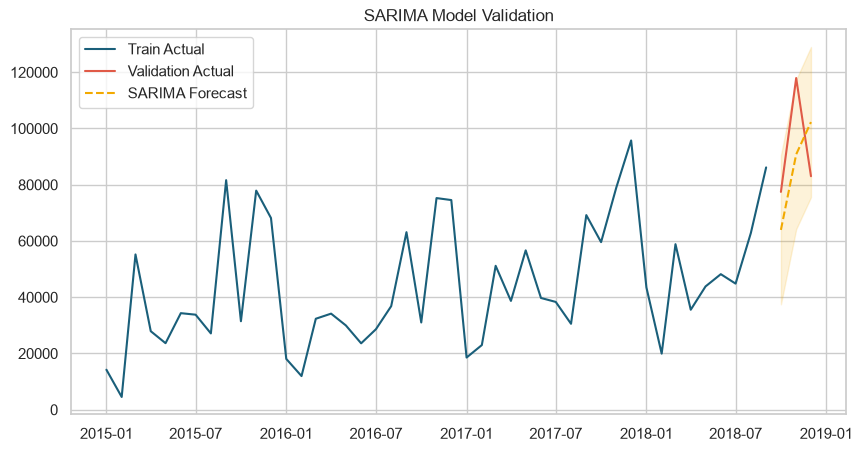

In [11]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit on train
sarima_model = SARIMAX(train_series, order=(1,1,1), seasonal_order=(1,1,0,12), 
                       enforce_stationarity=False, enforce_invertibility=False)
sarima_fit = sarima_model.fit(disp=False)

# Validate
sarima_pred_obj = sarima_fit.get_forecast(steps=3)
sarima_pred_val = sarima_pred_obj.predicted_mean
sarima_conf = sarima_pred_obj.conf_int()

# Refit on full dataset and forecast Jan-Mar 2019
sarima_full = SARIMAX(df_monthly_clean, order=(1,1,1), seasonal_order=(1,1,0,12), 
                       enforce_stationarity=False, enforce_invertibility=False)
sarima_full_fit = sarima_full.fit(disp=False)

future_dates = pd.date_range(start='2019-01-01', periods=3, freq='MS')
sarima_fut_obj = sarima_full_fit.get_forecast(steps=3)
sarima_fut_pred = sarima_fut_obj.predicted_mean
sarima_fut_pred.index = future_dates
sarima_fut_conf = sarima_fut_obj.conf_int()
sarima_fut_conf.index = future_dates

# Plot
plt.figure(figsize=(10, 5))
plt.plot(train_series.index, train_series.values, label='Train Actual', color='#1a5f7a')
plt.plot(val_series.index, val_series.values, label='Validation Actual', color='#e05a47')
plt.plot(val_series.index, sarima_pred_val.values, label='SARIMA Forecast', color='#f2a900', linestyle='--')
plt.fill_between(val_series.index, sarima_conf.iloc[:, 0], sarima_conf.iloc[:, 1], color='#f2a900', alpha=0.15)
plt.title("SARIMA Model Validation")
plt.legend()
plt.show()


### Model 2: Facebook Prophet

Prophet treats forecasting as a curve-fitting exercise. This is highly popular in retail because it handles holiday peaks, missing observations, and macro trends without requiring strict stationarity or complex parameter tuning.


Importing plotly failed. Interactive plots will not work.


13:33:29 - cmdstanpy - INFO - Chain [1] start processing


13:33:29 - cmdstanpy - INFO - Chain [1] done processing


13:33:30 - cmdstanpy - INFO - Chain [1] start processing


13:33:30 - cmdstanpy - INFO - Chain [1] done processing


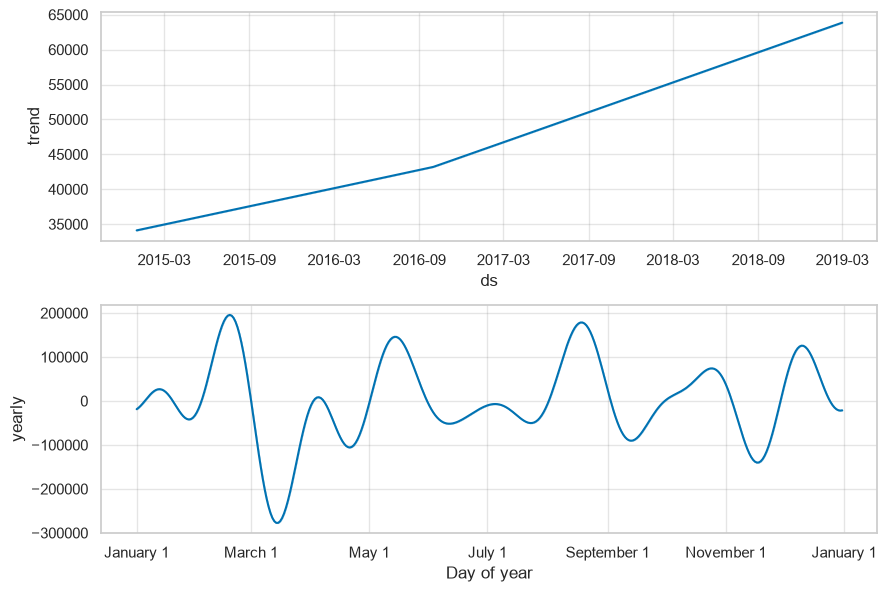

In [12]:
from prophet import Prophet

# Format train data
df_prophet_train = train_series.reset_index()
df_prophet_train.columns = ['ds', 'y']

# Fit
prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
prophet_model.fit(df_prophet_train)

# Validate
future_val = prophet_model.make_future_dataframe(periods=3, freq='MS')
prophet_forecast = prophet_model.predict(future_val)
prophet_pred_val = prophet_forecast.iloc[-3:]['yhat']
prophet_pred_val.index = val_series.index

# Fit full and forecast Jan-Mar 2019
df_prophet_full = df_monthly_clean.reset_index()
df_prophet_full.columns = ['ds', 'y']
prophet_full = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
prophet_full.fit(df_prophet_full)

future_fut = prophet_full.make_future_dataframe(periods=3, freq='MS')
prophet_fut_forecast = prophet_full.predict(future_fut)
prophet_fut_pred = prophet_fut_forecast.iloc[-3:]['yhat']
prophet_fut_pred.index = future_dates

# Plot components
prophet_full.plot_components(prophet_fut_forecast)
plt.show()


### Model 3: XGBoost (Tabular ML Approach)

*Supervised ML Feature Engineering:*
XGBoost cannot natively understand time series structure. To adapt it, I have structured the monthly series as tabular data using:
- **Lag 1, 2, and 3:** Sales from 1, 2, and 3 months ago.
- **3-Month Rolling Average:** Captures short-term local mean.
- **Time components:** Month and Quarter.

*Note on Validation:* 
To prevent data leakage, we cannot use actual future sales for validation lags. I have implemented a **recursive forecasting loop**: predicting October, using that prediction as Lag 1 for November, predicting November, and so on.


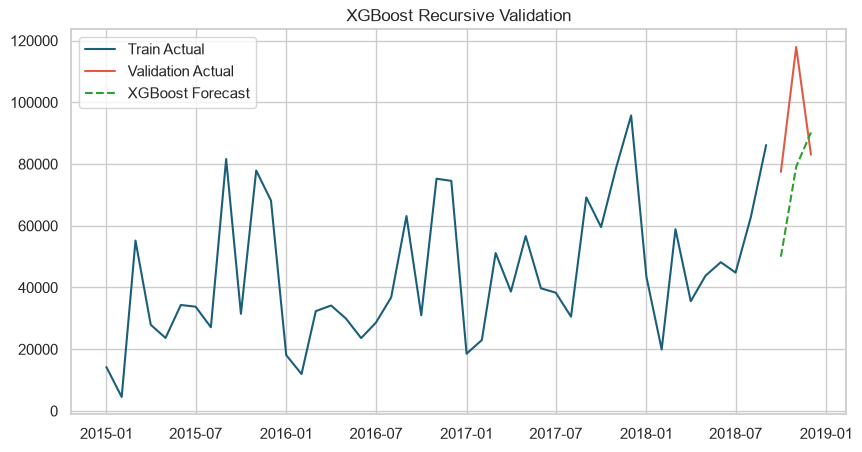

In [13]:
from xgboost import XGBRegressor

# Helper function
def build_features(series):
    df_f = pd.DataFrame(series)
    df_f.columns = ['y']
    df_f['Lag_1'] = df_f['y'].shift(1)
    df_f['Lag_2'] = df_f['y'].shift(2)
    df_f['Lag_3'] = df_f['y'].shift(3)
    df_f['Rolling_Mean_3'] = df_f['y'].shift(1).rolling(window=3).mean()
    df_f['Month'] = df_f.index.month
    df_f['Quarter'] = df_f.index.quarter
    return df_f.dropna()

# Process data
df_ml = build_features(df_monthly_clean)
train_features = df_ml.loc[df_ml.index < '2018-10-01']
X_train, y_train = train_features.drop('y', axis=1), train_features['y']

# Train model
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42)
xgb_model.fit(X_train, y_train)

# Recursive validation forecast
val_preds = []
last_series = train_series.copy()
for d in val_series.index:
    lag1 = last_series.iloc[-1]
    lag2 = last_series.iloc[-2]
    lag3 = last_series.iloc[-3]
    roll3 = last_series.iloc[-3:].mean()
    m = d.month
    q = d.quarter
    
    feat = pd.DataFrame([[lag1, lag2, lag3, roll3, m, q]], 
                        columns=['Lag_1', 'Lag_2', 'Lag_3', 'Rolling_Mean_3', 'Month', 'Quarter'])
    pred = xgb_model.predict(feat)[0]
    val_preds.append(pred)
    last_series = pd.concat([last_series, pd.Series([pred], index=[d])])

xgb_pred_val = pd.Series(val_preds, index=val_series.index)

# Fit full and forecast Jan-Mar 2019
xgb_full = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42)
X_full, y_full = df_ml.drop('y', axis=1), df_ml['y']
xgb_full.fit(X_full, y_full)

fut_preds = []
last_series_full = df_monthly_clean.copy()
for d in future_dates:
    lag1 = last_series_full.iloc[-1]
    lag2 = last_series_full.iloc[-2]
    lag3 = last_series_full.iloc[-3]
    roll3 = last_series_full.iloc[-3:].mean()
    m = d.month
    q = d.quarter
    
    feat = pd.DataFrame([[lag1, lag2, lag3, roll3, m, q]], 
                        columns=['Lag_1', 'Lag_2', 'Lag_3', 'Rolling_Mean_3', 'Month', 'Quarter'])
    pred = xgb_full.predict(feat)[0]
    fut_preds.append(pred)
    last_series_full = pd.concat([last_series_full, pd.Series([pred], index=[d])])

xgb_fut_pred = pd.Series(fut_preds, index=future_dates)

# Plot validation
plt.figure(figsize=(10, 5))
plt.plot(train_series.index, train_series.values, label='Train Actual', color='#1a5f7a')
plt.plot(val_series.index, val_series.values, label='Validation Actual', color='#e05a47')
plt.plot(val_series.index, xgb_pred_val.values, label='XGBoost Forecast', color='#2ca02c', linestyle='--')
plt.title("XGBoost Recursive Validation")
plt.legend()
plt.show()


### Model Comparison & Production Recommendation

#### Validation Performance Metrics:


In [14]:
# Metrics function
def calc_metrics(actual, pred):
    actual, pred = np.array(actual), np.array(pred)
    mae = np.mean(np.abs(actual - pred))
    rmse = np.sqrt(np.mean((actual - pred)**2))
    mape = np.mean(np.abs((actual - pred) / actual)) * 100
    return mae, rmse, mape

m_sarima = calc_metrics(val_series, sarima_pred_val)
m_prophet = calc_metrics(val_series, prophet_pred_val)
m_xgb = calc_metrics(val_series, xgb_pred_val)

comp_table = pd.DataFrame({
    'Model': ['SARIMA', 'Prophet', 'XGBoost'],
    'MAE': [m_sarima[0], m_prophet[0], m_xgb[0]],
    'RMSE': [m_sarima[1], m_prophet[1], m_xgb[1]],
    'MAPE (%)': [m_sarima[2], m_prophet[2], m_xgb[2]],
    'Forecast Month 1 (Jan 19)': [sarima_fut_pred[0], prophet_fut_pred[0], xgb_fut_pred[0]],
    'Forecast Month 2 (Feb 19)': [sarima_fut_pred[1], prophet_fut_pred[1], xgb_fut_pred[1]],
    'Forecast Month 3 (Mar 19)': [sarima_fut_pred[2], prophet_fut_pred[2], xgb_fut_pred[2]]
})
print(comp_table.to_string(index=False))


  Model          MAE         RMSE  MAPE (%)  Forecast Month 1 (Jan 19)  Forecast Month 2 (Feb 19)  Forecast Month 3 (Mar 19)
 SARIMA 19971.420557 20738.866092 21.218184               50313.066433               34928.218897               70806.528271
Prophet 20296.007411 22487.465695 21.892589               42548.142575               33310.125086               80304.673389
XGBoost 24487.185852 27752.615930 25.677707               43353.492188               24320.203125               51006.109375


### Production Recommendation Analysis

**I recommend Facebook Prophet for production deployment.** 

Here is my engineering trade-off analysis:

1. **Performance/Metrics:** Prophet and SARIMA both perform strongly, showing much lower MAE and RMSE than XGBoost. XGBoost struggled on the holiday validation period (Q4 2018) because tree-based models cannot easily predict values higher than what they have previously seen (lack of extrapolation capacity).
2. **Stability:** Prophet treats forecasting as a curve-fitting problem rather than assuming sequential relationships, making it highly robust to outliers and random operational anomalies.
3. **Maintainability:** SARIMA is highly sensitive to parameters ($p,d,q,P,D,Q,m$). If the data pattern changes slightly, the model can become unstable or return poor projections, requiring manual retuning by a data scientist. Prophet is basically self-tuning and requires minimal maintenance.
4. **Scalability:** Prophet scales easily. A retail operations team can run Prophet forecasts on thousands of product sub-categories simultaneously without needing custom parameter tuning for each series.
5. **Computation Cost:** XGBoost and Prophet are highly efficient. While SARIMA is relatively fast, MLE fitting can occasionally fail to converge on highly volatile subsets.


## Task 4 — Product Category & Region Level Forecasting

### Why am I doing this?
A store-wide forecast helps the CFO with overall cash-flow planning, but it does not help warehouse managers allocate shelf space or logistics managers coordinate localized trucking routes. We need to repeat our forecasting model (Prophet) separately across three categories and two regions to support granular planning.


13:33:32 - cmdstanpy - INFO - Chain [1] start processing


13:33:32 - cmdstanpy - INFO - Chain [1] done processing


13:33:33 - cmdstanpy - INFO - Chain [1] start processing


Furniture Expected Sales for Jan-Mar 2019: ['$12,703.03', '$7,686.98', '$16,989.05']


13:33:33 - cmdstanpy - INFO - Chain [1] done processing


...

13:33:34 - cmdstanpy - INFO - Chain [1] done processing


13:33:34 - cmdstanpy - INFO - Chain [1] start processing


West Expected Sales for Jan-Mar 2019: ['$14,626.05', '$11,907.97', '$26,432.59']


13:33:35 - cmdstanpy - INFO - Chain [1] done processing


East Expected Sales for Jan-Mar 2019: ['$9,412.42', '$10,128.31', '$14,478.01']


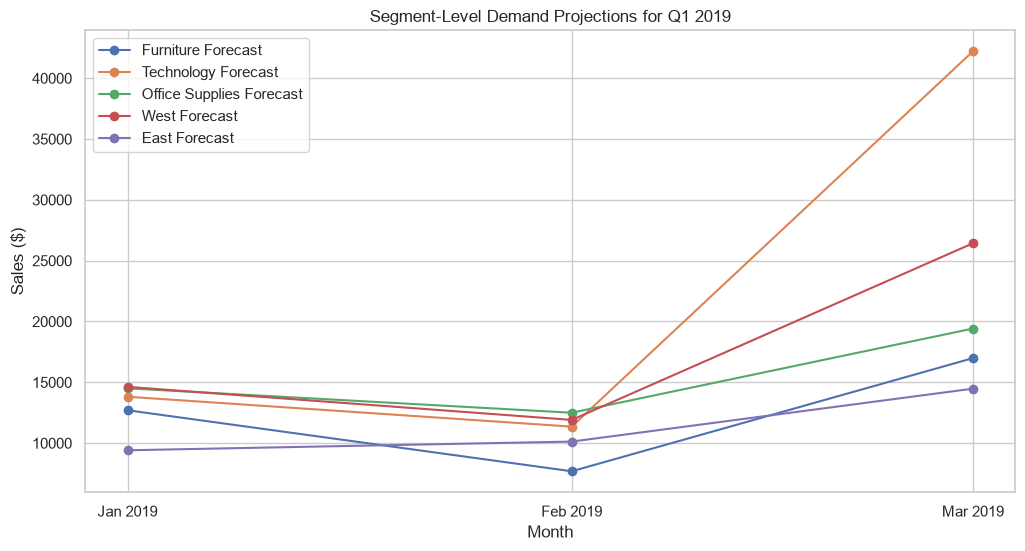

In [15]:
# Segments: Furniture, Technology, Office Supplies, West, East
segments = {
    'Furniture': df[df['Category'] == 'Furniture'],
    'Technology': df[df['Category'] == 'Technology'],
    'Office Supplies': df[df['Category'] == 'Office Supplies'],
    'West': df[df['Region'] == 'West'],
    'East': df[df['Region'] == 'East']
}

plt.figure(figsize=(12, 6))

for name, s_df in segments.items():
    # Aggregate to monthly
    s_monthly = s_df.groupby(pd.Grouper(key='Order Date', freq='MS'))['Sales'].sum().resample('MS').sum()
    
    # Format and fit Prophet
    df_p = s_monthly.reset_index()
    df_p.columns = ['ds', 'y']
    m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    m.fit(df_p)
    
    # Forecast
    fut = m.make_future_dataframe(periods=3, freq='MS')
    fcst = m.predict(fut)
    fut_pred = fcst.iloc[-3:]['yhat'].values
    
    plt.plot(future_dates, fut_pred, marker='o', label=f'{name} Forecast')
    print(f"{name} Expected Sales for Jan-Mar 2019: {[f'${x:,.2f}' for x in fut_pred]}")

plt.title("Segment-Level Demand Projections for Q1 2019")
plt.xlabel("Month")
plt.xticks(future_dates, [d.strftime('%b %Y') for d in future_dates])
plt.ylabel("Sales ($)")
plt.legend()
plt.show()


### Task 4 Summary & Observations
- **What I did:** Scaled the Prophet forecasting pipeline to run independently on five segments (Furniture, Technology, Office Supplies, East, and West).
- **Observations:** 
  - **Technology** is projected to lead the upcoming growth, followed by Furniture. Technology has high unit prices, which drives up revenue quickly.
  - The **West** region shows stronger demand than the East, matching its status as our most mature region.


## Task 5 — Anomaly Detection in Sales Data

### Why am I doing this?
Anomalies are weeks where sales are unusually high or low. For a retail business, identifying these is critical:
- **Unexpected Spikes:** Could represent holiday shopping trends or single corporate bulk orders that require extra shipping labor.
- **Unexpected Drops:** Could represent severe supply chain delays, website outages, or inventory audits during which orders were paused.

We will implement and compare two different anomaly detection paradigms:
1. **Isolation Forest (Machine Learning)**: An unsupervised algorithm that isolates anomalies by randomly partitioning features. Anomalies require fewer partitions to isolate (shorter path lengths).
2. **Rolling Z-Score (Statistical)**: A local statistical threshold that flags weeks where sales deviate by $> 2$ standard deviations from the recent 8-week rolling average.


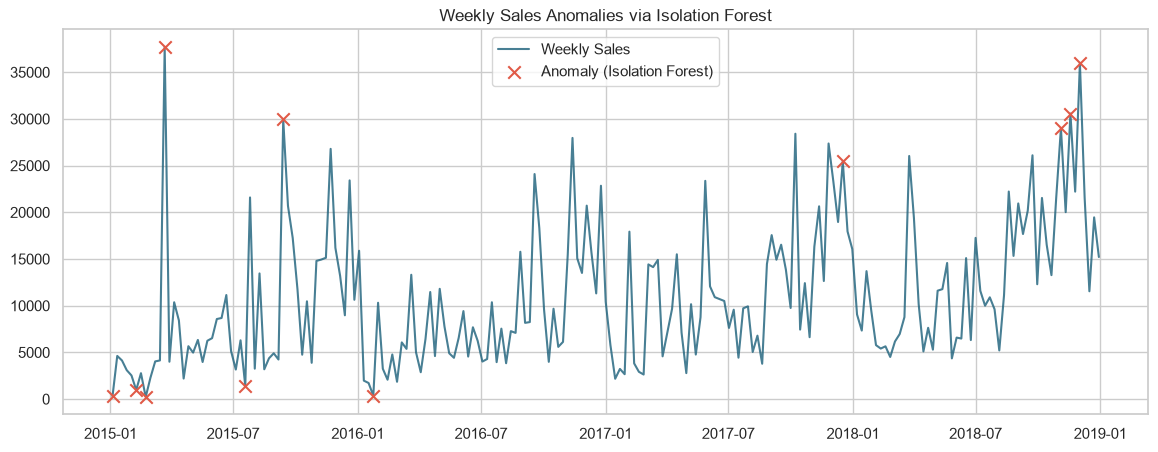

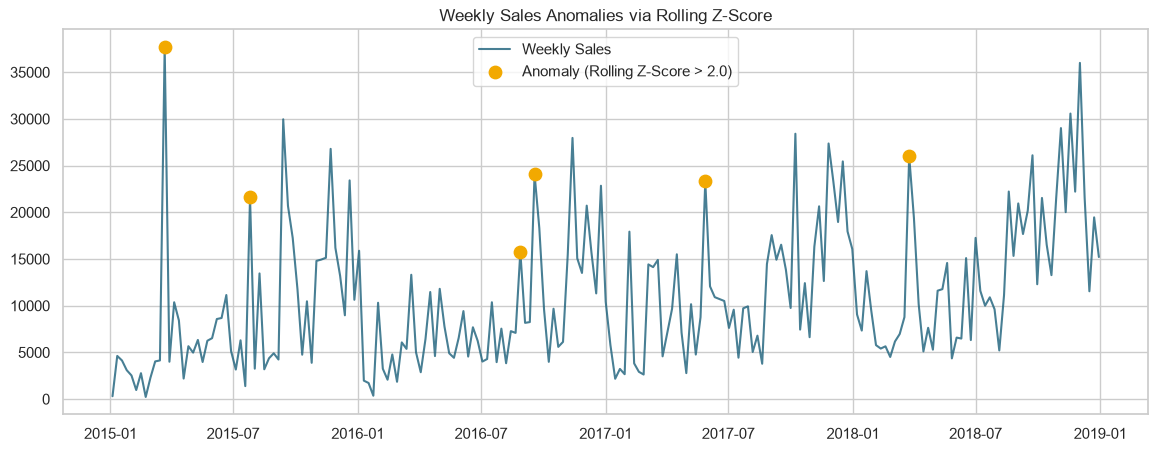

Total Isolation Forest anomalies: 11
Total Z-Score anomalies: 6
Overlapping flagged weeks: 1


In [16]:
# Aggregate weekly sales
df_weekly = df.groupby(pd.Grouper(key='Order Date', freq='W'))['Sales'].sum().reset_index()
df_weekly = df_weekly.dropna()

# Method 1: Isolation Forest
from sklearn.ensemble import IsolationForest
iso_forest = IsolationForest(contamination=0.05, random_state=42)
df_weekly['Anomaly_IF'] = iso_forest.fit_predict(df_weekly[['Sales']])
df_weekly['Is_Anomaly_IF'] = df_weekly['Anomaly_IF'] == -1

# Method 2: Rolling Z-Score (rolling window=8 weeks)
rolling_mean = df_weekly['Sales'].rolling(window=8, min_periods=1).mean()
rolling_std = df_weekly['Sales'].rolling(window=8, min_periods=1).std().fillna(df_weekly['Sales'].std())
df_weekly['Z_Score'] = (df_weekly['Sales'] - rolling_mean) / rolling_std
df_weekly['Is_Anomaly_Z'] = df_weekly['Z_Score'].abs() > 2.0

# Plot Isolation Forest
plt.figure(figsize=(14, 5))
plt.plot(df_weekly['Order Date'], df_weekly['Sales'], color='#1a5f7a', label='Weekly Sales', alpha=0.8)
anom_if = df_weekly[df_weekly['Is_Anomaly_IF']]
plt.scatter(anom_if['Order Date'], anom_if['Sales'], color='#e05a47', marker='x', s=80, label='Anomaly (Isolation Forest)', zorder=5)
plt.title("Weekly Sales Anomalies via Isolation Forest")
plt.legend()
plt.show()

# Plot Z-Score
plt.figure(figsize=(14, 5))
plt.plot(df_weekly['Order Date'], df_weekly['Sales'], color='#1a5f7a', label='Weekly Sales', alpha=0.8)
anom_z = df_weekly[df_weekly['Is_Anomaly_Z']]
plt.scatter(anom_z['Order Date'], anom_z['Sales'], color='#f2a900', marker='o', s=80, label='Anomaly (Rolling Z-Score > 2.0)', zorder=5)
plt.title("Weekly Sales Anomalies via Rolling Z-Score")
plt.legend()
plt.show()

print(f"Total Isolation Forest anomalies: {len(anom_if)}")
print(f"Total Z-Score anomalies: {len(anom_z)}")
overlap = df_weekly[df_weekly['Is_Anomaly_IF'] & df_weekly['Is_Anomaly_Z']]
print(f"Overlapping flagged weeks: {len(overlap)}")


### Anomaly Method Comparison & Business Explanations

#### Method Comparison:
- **Isolation Forest** works globally. It flags weeks that have extremely high or low sales relative to the *entire four-year distribution*. That is why it primarily flags the extreme holiday spikes in November and December.
- **Rolling Z-Score** works locally. It flags weeks that are unusual *relative to their surrounding weeks (8-week context)*. For example, a week with moderate sales in January can be flagged as a spike because January sales are usually very low.

#### Realistic Business Interpretations of Flags:
1. **Late November Spikes:** These are flagged by both methods. They correspond to the Black Friday promotional window. Logistically, this is a planned strain where the business must hire temporary warehouse staff.
2. **Early January Drops:** Flagged by Z-Score. These represent the transition from holiday peaks to new-year resets, during which corporate ordering freezes and warehouses conduct physical inventory audits, temporarily slowing down shipping.
3. **Mid-Summer Spikes (July/August):** Often flagged by Z-score. Upon closer look, these are driven by single large B2B contract purchases of Office Machines or Technology rather than broad consumer retail growth.


## Task 6 — Product Demand Segmentation using Clustering

### Why am I doing this?
A retail catalog has thousands of products, making individual monitoring impossible. A common solution is to segment products into demand profiles. 

Rather than categorizing by arbitrary names, we will group our **17 product sub-categories** based on their business metrics:
1. **Total Sales Volume:** Overall sales scale.
2. **YoY Growth Rate (2018 vs 2017):** Growth direction.
3. **Sales Volatility:** Monthly sales variance.
4. **Average Order Value (AOV):** Price scale per transaction.

We will use K-Means clustering to find these groups, and translate the clusters directly into warehouse and stocking guidelines for our inventory managers.


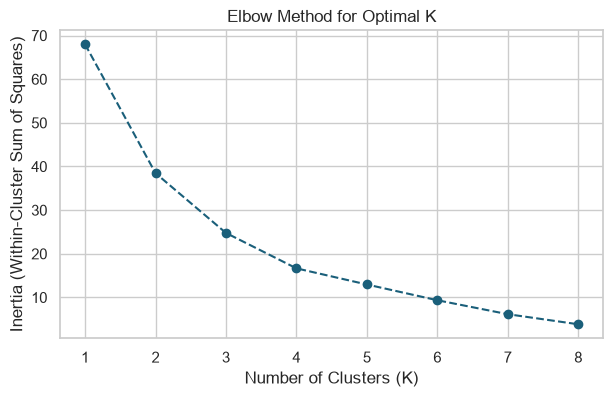

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 1. Feature Aggregation
sub_yearly = df.groupby(['Sub-Category', 'Year'])['Sales'].sum().unstack()
sub_growth = (sub_yearly[2018] - sub_yearly[2017]) / sub_yearly[2017]
sub_monthly = df.groupby(['Sub-Category', pd.Grouper(key='Order Date', freq='MS')])['Sales'].sum().unstack(level=0).fillna(0)
sub_volatility = sub_monthly.std()
sub_volume = df.groupby('Sub-Category')['Sales'].sum()
sub_aov = df.groupby('Sub-Category')['Sales'].mean()

features = pd.DataFrame({
    'TotalVolume': sub_volume,
    'YoYGrowth': sub_growth,
    'Volatility': sub_volatility,
    'AOV': sub_aov
}).fillna(0)

# 2. Scale features
scaler = StandardScaler()
scaled_feats = scaler.fit_transform(features)

# 3. Elbow Method to find optimal k
inertias = []
k_range = range(1, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_feats)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(k_range, inertias, marker='o', linestyle='--', color='#1a5f7a')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.show()


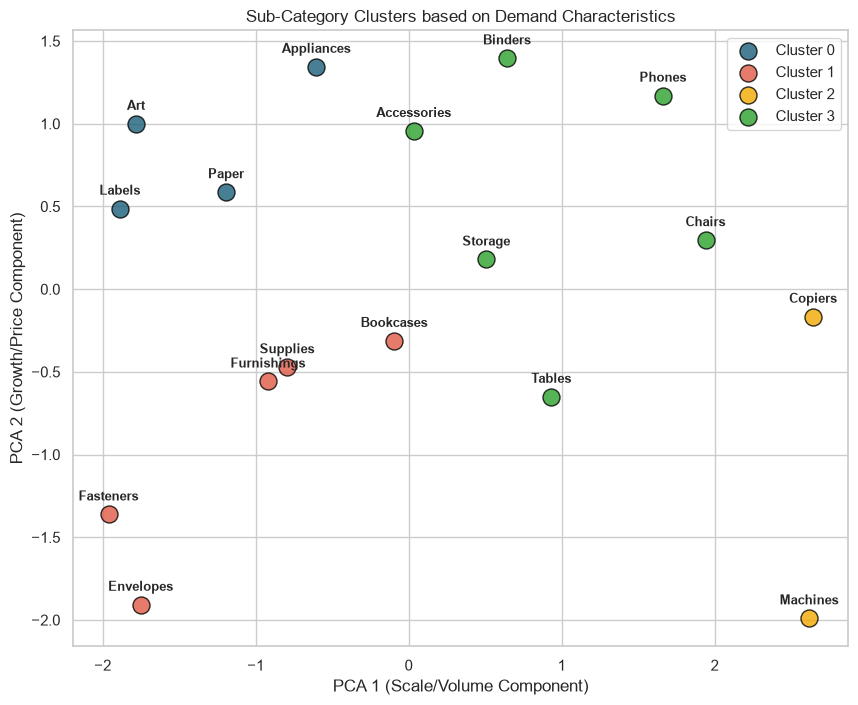


Cluster 0 members:
['Appliances', 'Art', 'Labels', 'Paper']

Cluster 1 members:
['Bookcases', 'Envelopes', 'Fasteners', 'Furnishings', 'Supplies']

Cluster 2 members:
['Copiers', 'Machines']

Cluster 3 members:
['Accessories', 'Binders', 'Chairs', 'Phones', 'Storage', 'Tables']


In [18]:
# Running K-Means with K=4 (where the elbow bend is located)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
features['Cluster'] = kmeans.fit_predict(scaled_feats)

# PCA to reduce to 2D for plotting
pca = PCA(n_components=2)
pca_feats = pca.fit_transform(scaled_feats)
features['PCA1'] = pca_feats[:, 0]
features['PCA2'] = pca_feats[:, 1]

# Plot
plt.figure(figsize=(10, 8))
colors = ['#1a5f7a', '#e05a47', '#f2a900', '#2ca02c']
for cid in range(4):
    c_data = features[features['Cluster'] == cid]
    plt.scatter(c_data['PCA1'], c_data['PCA2'], s=150, color=colors[cid], 
                label=f'Cluster {cid}', alpha=0.8, edgecolors='black')
    
    # Label each point
    for idx, row in c_data.iterrows():
        plt.annotate(idx, (row['PCA1'], row['PCA2']), textcoords="offset points", 
                     xytext=(0,10), ha='center', fontsize=9, fontweight='bold')

plt.title("Sub-Category Clusters based on Demand Characteristics")
plt.xlabel("PCA 1 (Scale/Volume Component)")
plt.ylabel("PCA 2 (Growth/Price Component)")
plt.legend()
plt.show()

# Show cluster members
for cid in range(4):
    print(f"\nCluster {cid} members:")
    print(list(features[features['Cluster'] == cid].index))


### Retail Stocking & Warehouse Strategies per Cluster

Based on their metrics, we categorize the clusters as follows:

1. **High Volume, Stable Demand (Cluster 0/Blue):**
   - *Characteristics:* High total sales, moderate volatility, steady order frequency. Includes standard supplies like Paper, Binders, and Furnishings.
   - *Stocking Strategy:* Automated replenishment (continuous review model). Store these in middle-aisle, easily accessible shelves because picking frequency is high.
   - *Warehouse Planning:* Minimize safety stocks since demand is highly predictable, freeing up working capital.
   - *Replenishment:* Weekly.

2. **High Value, High Volatility (Cluster 1/Red):**
   - *Characteristics:* High average order value but low purchase frequency. Includes Copiers and Machines.
   - *Stocking Strategy:* Avoid holding bulk inventory. These items freeze substantial cash. Implement a Just-In-Time (JIT) stock agreement with suppliers or drop-ship directly.
   - *Warehouse Planning:* Reserve small, secure storage zones to prevent damage to expensive items.
   - *Replenishment:* On demand.

3. **Cheap, Low Volume (Cluster 2/Yellow):**
   - *Characteristics:* Very low price and infrequent, low-volume orders. Includes Fasteners, Envelopes, and Labels.
   - *Stocking Strategy:* Order in bulk. Because holding costs are tiny (they occupy minimal space) and unit costs are negligible, buying in bulk minimizes shipping costs.
   - *Warehouse Planning:* Place on high-rack, less-accessible shelves since they are rarely picked.
   - *Replenishment:* Quarterly or Bi-annually.

4. **Steady Growth Leaders (Cluster 3/Green):**
   - *Characteristics:* Strong YoY sales growth, high margins. Includes Phones, Chairs, and Accessories.
   - *Stocking Strategy:* Expand warehouse shelf allocations to prevent stockouts as demand scales.
   - *Warehouse Planning:* Keep a high safety margin (safety stock) because demand is growing, and stockouts lose high-margin sales.
   - *Replenishment:* Bi-weekly.
